In [11]:
import os

raw_base = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007329"

print("Searching for ratings files...")
for root, dirs, files in os.walk(raw_base):
    for file in files:
        if "rating" in file.lower() or "behavioral" in file.lower():
            print(os.path.join(root, file))
print("Search complete.")

Searching for ratings files...
/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv
Search complete.


Fetching events and ratings from OpenNeuro...
Fitting the GLM...
GLM fit complete for visualmemory task.


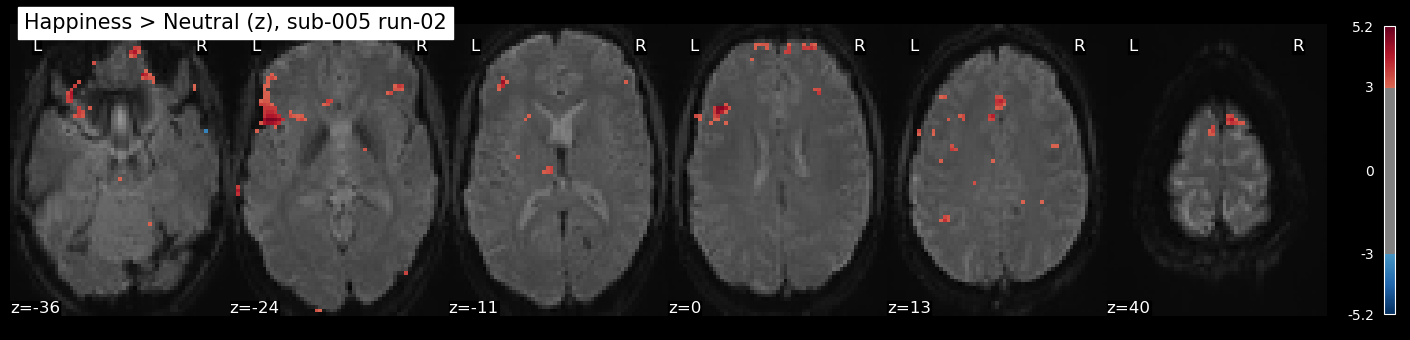

In [16]:
#SINGLE SUBJECT GLM

import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import mean_img
from nilearn.plotting import plot_stat_map, show

# 1. Setup local paths for the BOLD data
deriv = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007384/sub-sid000005/ses-1/func"
run   = "run-02"

bold   = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{run}_space-T1w_desc-preproc_bold.nii.gz"
mask   = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{run}_space-T1w_desc-brain_mask.nii.gz"
conf_f = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{run}_desc-confounds_timeseries.tsv"

# 2. Bypass DataLad and read the events and ratings directly from OpenNeuro's S3 bucket
events_url = f"https://s3.amazonaws.com/openneuro.org/ds007329/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-visualmemory_{run}_events.tsv"
ratings_url = "https://s3.amazonaws.com/openneuro.org/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv"

print("Fetching events and ratings from OpenNeuro...")
events = pd.read_csv(events_url, sep="\t")
ratings = pd.read_csv(ratings_url, sep="\t")

# 3. Merge! The events file uses 'trial_type' for the clip name, and ratings uses 'clip'
events = events.merge(ratings, left_on="trial_type", right_on="clip", how="left")

# Overwrite trial_type to be the 'emotion' column
events["trial_type"] = events["emotion"]
events = events[["onset", "duration", "trial_type"]].dropna()

# 4. Isolate Confounds (loaded locally)
conf = pd.read_csv(conf_f, sep="\t")
motion = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
confounds = conf[motion].fillna(0)

# 5. Fit the GLM
print("Fitting the GLM...")
glm = FirstLevelModel(t_r=1.0, mask_img=mask, high_pass=1/128, smoothing_fwhm=5)
glm = glm.fit(bold, events=events, confounds=confounds)
print("GLM fit complete for visualmemory task.")

# 6. Compute the Contrast: Happiness > Neutral
# Using a try/except block to handle whether the labels inside the TSV are capitalized or lowercase
try:
    z_happy_vs_neutral = glm.compute_contrast("Happiness - Neutral", output_type="z_score")
except ValueError:
    print("Labels are likely lowercase. Falling back to lowercase contrast names...")
    z_happy_vs_neutral = glm.compute_contrast("happiness - neutral", output_type="z_score")

# 7. Plot using the functional mean as the background to fix the floating artifact
background_img = mean_img(bold)
plot_stat_map(z_happy_vs_neutral, 
              bg_img=background_img, 
              threshold=3.0,
              title="Happiness > Neutral (z), sub-005 run-02",
              display_mode="z", 
              cut_coords=6)
show()

Building visual ROI from localizer data...
Visual ROI created with 12233 voxels.
Fitting GLM for emotions on visualmemory task...
Emotions present in run-02: ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Surprise']


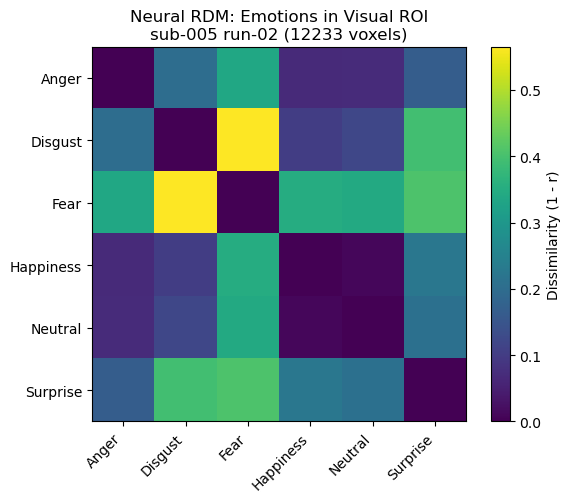

In [19]:
#SINGLE SUBJECT RDM 

import numpy as np
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SETUP PATHS
# ---------------------------------------------------------
deriv = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007384/sub-sid000005/ses-1/func"
raw   = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007329"

# Localizer paths (Used to build an independent Visual ROI)
loc_run = "run-01"
bold_loc = f"{deriv}/sub-sid000005_ses-1_task-localizer_{loc_run}_space-T1w_desc-preproc_bold.nii.gz"
mask_loc = f"{deriv}/sub-sid000005_ses-1_task-localizer_{loc_run}_space-T1w_desc-brain_mask.nii.gz"
ev_loc   = f"{raw}/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-localizer_{loc_run}_events.tsv"
conf_loc = f"{deriv}/sub-sid000005_ses-1_task-localizer_{loc_run}_desc-confounds_timeseries.tsv"

# Visualmemory paths (Used to test the Emotion representations)
mem_run = "run-02"
bold_mem = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{mem_run}_space-T1w_desc-preproc_bold.nii.gz"
mask_mem = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{mem_run}_space-T1w_desc-brain_mask.nii.gz"
conf_mem = f"{deriv}/sub-sid000005_ses-1_task-visualmemory_{mem_run}_desc-confounds_timeseries.tsv"

# THE FIX: Use OpenNeuro URLs for BOTH the events and the ratings!
ev_mem_url = f"https://s3.amazonaws.com/openneuro.org/ds007329/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-visualmemory_{mem_run}_events.tsv"
ratings_url = "https://s3.amazonaws.com/openneuro.org/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv"

# ---------------------------------------------------------
# 2. BUILD INDEPENDENT VISUAL ROI (From Localizer)
# ---------------------------------------------------------
print("Building visual ROI from localizer data...")
events_loc = pd.read_csv(ev_loc, sep="\t")
loc_cats = ["faces", "bodies", "objects", "scenes", "scrambled_objects"]
events_loc = events_loc[events_loc["stim_type"].isin(loc_cats)][["onset", "duration", "stim_type"]].rename(columns={"stim_type": "trial_type"})
confounds_loc = pd.read_csv(conf_loc, sep="\t")[["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]].fillna(0)

glm_loc = FirstLevelModel(t_r=1.0, mask_img=mask_loc, high_pass=1/128, smoothing_fwhm=5)
glm_loc.fit(bold_loc, events=events_loc, confounds=confounds_loc)

# Create ROI from all visual stimulation > baseline
visual_z = glm_loc.compute_contrast("0.2*faces + 0.2*bodies + 0.2*objects + 0.2*scenes + 0.2*scrambled_objects", output_type="z_score")
roi_mask = math_img("img > 3.1", img=visual_z)
n_vox = int(roi_mask.get_fdata().sum())
print(f"Visual ROI created with {n_vox} voxels.")

# ---------------------------------------------------------
# 3. FIT GLM FOR EMOTIONS (Visualmemory Run)
# ---------------------------------------------------------
print("Fitting GLM for emotions on visualmemory task...")

# Read BOTH files from their web URLs
events_mem = pd.read_csv(ev_mem_url, sep="\t")
ratings = pd.read_csv(ratings_url, sep="\t")

# Merge and overwrite trial_type with the 'emotion' label
events_mem = events_mem.merge(ratings, left_on="trial_type", right_on="clip", how="left")

# Capitalize emotion labels for cleaner plotting
events_mem["trial_type"] = events_mem["emotion"].str.capitalize()
events_mem = events_mem[["onset", "duration", "trial_type"]].dropna()

confounds_mem = pd.read_csv(conf_mem, sep="\t")[["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]].fillna(0)

glm_mem = FirstLevelModel(t_r=1.0, mask_img=mask_mem, high_pass=1/128, smoothing_fwhm=5)
glm_mem.fit(bold_mem, events=events_mem, confounds=confounds_mem)

# ---------------------------------------------------------
# 4. EXTRACT PATTERNS AND BUILD RDM
# ---------------------------------------------------------
# Dynamically find which emotions actually appeared in this specific run
present_emotions = sorted(events_mem["trial_type"].unique())
print(f"Emotions present in {mem_run}: {present_emotions}")

# Extract pattern (beta map) for each emotion
beta_maps = {e: glm_mem.compute_contrast(e, output_type="effect_size") for e in present_emotions}
masker = NiftiMasker(mask_img=roi_mask).fit()
patterns = np.vstack([masker.transform(beta_maps[e]) for e in present_emotions])

# Calculate 1 - correlation
rdm = squareform(pdist(patterns, metric="correlation"))

# ---------------------------------------------------------
# 5. PLOT NEURAL RDM
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rdm, cmap="viridis")

ax.set_xticks(range(len(present_emotions)))
ax.set_yticks(range(len(present_emotions)))
ax.set_xticklabels(present_emotions, rotation=45, ha="right")
ax.set_yticklabels(present_emotions)
ax.set_title(f"Neural RDM: Emotions in Visual ROI\nsub-005 {mem_run} ({n_vox} voxels)")

plt.colorbar(im, label="Dissimilarity (1 - r)")
plt.tight_layout()
plt.show()

Found 21 subjects. Starting group analysis...

Processing sub-sid000005...
  -> OK
Processing sub-sid000007...
  -> OK
Processing sub-sid000009...
  -> OK
Processing sub-sid000010...
  -> OK
Processing sub-sid000013...
  -> OK
Processing sub-sid000020...
  -> OK
Processing sub-sid000021...
  -> OK
Processing sub-sid000024...
  -> OK
Processing sub-sid000029...
  -> OK
Processing sub-sid000034...
  -> OK
Processing sub-sid000052...
  -> OK
Processing sub-sid000114...
  -> OK
Processing sub-sid000120...
  -> OK
Processing sub-sid000134...
  -> OK
Processing sub-sid000142...
  -> OK
Processing sub-sid000278...
  -> OK
Processing sub-sid000416...
  -> OK
Processing sub-sid000499...
  -> OK
Processing sub-sid000522...
  -> OK
Processing sub-sid000535...
  -> OK
Processing sub-sid000560...
  -> OK

Successfully processed 21 subjects: ['sub-sid000005', 'sub-sid000007', 'sub-sid000009', 'sub-sid000010', 'sub-sid000013', 'sub-sid000020', 'sub-sid000021', 'sub-sid000024', 'sub-sid000029', 'sub-s

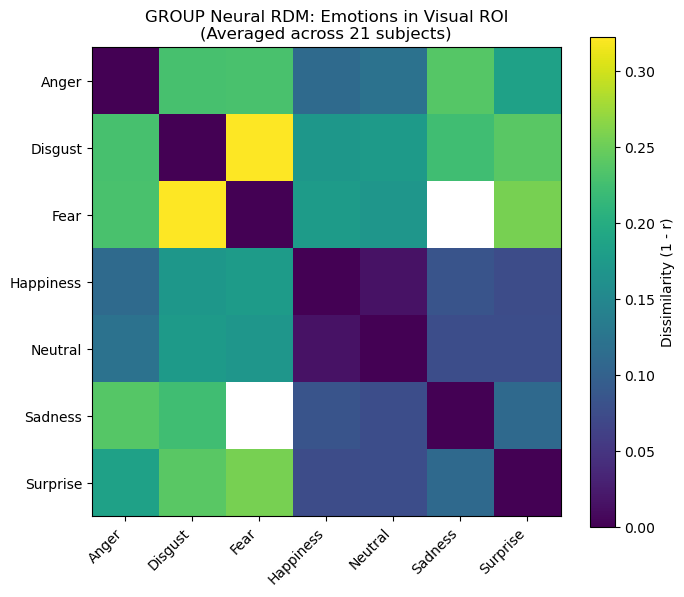

In [29]:
#GROUP IMPORT AND GROUP RDM

import os, urllib.request, numpy as np, pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

DERIV_SHARED = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007384"
S3_DERIV     = "https://s3.amazonaws.com/openneuro.org/ds007384"
CACHE        = os.path.expanduser("~/budapest_cache")   # writable; shared mount is read-only
os.makedirs(CACHE, exist_ok=True)

def fetch(sub, fname):
    """Readable local path: use shared read-only copy if present, else download from public S3."""
    rel    = f"{sub}/ses-1/func/{fname}"
    shared = os.path.join(DERIV_SHARED, rel)
    if os.path.exists(shared):                 # broken annex symlinks return False here
        return shared
    local = os.path.join(CACHE, rel)
    os.makedirs(os.path.dirname(local), exist_ok=True)
    if not os.path.exists(local):
        urllib.request.urlretrieve(f"{S3_DERIV}/{rel}", local)
    return local

ratings = pd.read_csv("https://s3.amazonaws.com/openneuro.org/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv", sep="\t")
ALL_EMOTIONS = ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']
subjects = sorted(d for d in os.listdir(DERIV_SHARED) if d.startswith("sub-") and not d.endswith(".html"))
print(f"Found {len(subjects)} subjects. Starting group analysis...\n")

group_rdms, used = [], []
for sub in subjects:
    try:
        print(f"Processing {sub}...")
        # A. Localizer ROI
        bold_loc = fetch(sub, f"{sub}_ses-1_task-localizer_run-01_space-T1w_desc-preproc_bold.nii.gz")
        mask_loc = fetch(sub, f"{sub}_ses-1_task-localizer_run-01_space-T1w_desc-brain_mask.nii.gz")
        conf_loc = fetch(sub, f"{sub}_ses-1_task-localizer_run-01_desc-confounds_timeseries.tsv")
        ev_loc_url = f"https://s3.amazonaws.com/openneuro.org/ds007329/{sub}/ses-1/func/{sub}_ses-1_task-localizer_run-01_events.tsv"

        events_loc = pd.read_csv(ev_loc_url, sep="\t")
        events_loc = events_loc[events_loc["stim_type"].isin(["faces","bodies","objects","scenes","scrambled_objects"])][["onset","duration","stim_type"]].rename(columns={"stim_type":"trial_type"})
        confounds_loc = pd.read_csv(conf_loc, sep="\t")[["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]].fillna(0)

        glm_loc = FirstLevelModel(t_r=1.0, mask_img=mask_loc, high_pass=1/128, smoothing_fwhm=5)
        glm_loc.fit(bold_loc, events=events_loc, confounds=confounds_loc)
        visual_z = glm_loc.compute_contrast("0.2*faces + 0.2*bodies + 0.2*objects + 0.2*scenes + 0.2*scrambled_objects", output_type="z_score")
        roi_mask = math_img("img > 3.1", img=visual_z)
        if int(roi_mask.get_fdata().sum()) < 100:
            roi_mask = math_img("img > 2.3", img=visual_z)

        # B. Visualmemory GLM (run-02)
        bold_mem = fetch(sub, f"{sub}_ses-1_task-visualmemory_run-02_space-T1w_desc-preproc_bold.nii.gz")
        mask_mem = fetch(sub, f"{sub}_ses-1_task-visualmemory_run-02_space-T1w_desc-brain_mask.nii.gz")
        conf_mem = fetch(sub, f"{sub}_ses-1_task-visualmemory_run-02_desc-confounds_timeseries.tsv")
        ev_mem_url = f"https://s3.amazonaws.com/openneuro.org/ds007329/{sub}/ses-1/func/{sub}_ses-1_task-visualmemory_run-02_events.tsv"

        events_mem = pd.read_csv(ev_mem_url, sep="\t").merge(ratings, left_on="trial_type", right_on="clip", how="left")
        events_mem["trial_type"] = events_mem["emotion"].str.capitalize()
        events_mem = events_mem[["onset","duration","trial_type"]].dropna()
        confounds_mem = pd.read_csv(conf_mem, sep="\t")[["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]].fillna(0)

        glm_mem = FirstLevelModel(t_r=1.0, mask_img=mask_mem, high_pass=1/128, smoothing_fwhm=5)
        glm_mem.fit(bold_mem, events=events_mem, confounds=confounds_mem)

        # C. RDM (standardized 7x7)
        present = sorted(events_mem["trial_type"].unique())
        beta = {e: glm_mem.compute_contrast(e, output_type="effect_size") for e in present}
        masker = NiftiMasker(mask_img=roi_mask).fit()
        patterns = np.vstack([masker.transform(beta[e]) for e in present])
        sub_rdm = squareform(pdist(patterns, metric="correlation"))

        full = np.full((7, 7), np.nan)
        for i, a in enumerate(ALL_EMOTIONS):
            for j, b in enumerate(ALL_EMOTIONS):
                if a in present and b in present:
                    full[i, j] = sub_rdm[present.index(a), present.index(b)]
        group_rdms.append(full); used.append(sub)
        print("  -> OK")
    except Exception as e:
        print(f"  -> Failed: {e}")

print(f"\nSuccessfully processed {len(group_rdms)} subjects: {used}")
if len(group_rdms) < 2:
    raise RuntimeError("Still <2 subjects — check the wget test above and free disk in your home dir.")

mean_rdm = np.nanmean(np.stack(group_rdms), axis=0)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mean_rdm, cmap="viridis")
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xticklabels(ALL_EMOTIONS, rotation=45, ha="right"); ax.set_yticklabels(ALL_EMOTIONS)
ax.set_title(f"GROUP Neural RDM: Emotions in Visual ROI\n(Averaged across {len(group_rdms)} subjects)")
plt.colorbar(im, label="Dissimilarity (1 - r)"); plt.tight_layout(); plt.show()

In [30]:
# whether that pair is reliably more similar or more distinct
import numpy as np, pandas as pd
coverage = np.sum(~np.isnan(np.stack(group_rdms)), axis=0)
print(pd.DataFrame(coverage, index=ALL_EMOTIONS, columns=ALL_EMOTIONS))

           Anger  Disgust  Fear  Happiness  Neutral  Sadness  Surprise
Anger         10        8     6         10       10        4        10
Disgust        8       13     5         13       13        7        13
Fear           6        5     6          6        6        0         6
Happiness     10       13     6         21       21       13        21
Neutral       10       13     6         21       21       13        21
Sadness        4        7     0         13       13       13        13
Surprise      10       13     6         21       21       13        21


sub-sid000005: already done, skipping
sub-sid000007: already done, skipping
sub-sid000009: already done, skipping
sub-sid000010: already done, skipping
sub-sid000013: already done, skipping
sub-sid000020: 12 runs, 7/7 emotions -> SAVED
sub-sid000021: 12 runs, 7/7 emotions -> SAVED
sub-sid000024: 12 runs, 7/7 emotions -> SAVED
sub-sid000029: 12 runs, 7/7 emotions -> SAVED
sub-sid000034: 12 runs, 7/7 emotions -> SAVED
sub-sid000052: 12 runs, 7/7 emotions -> SAVED
sub-sid000114: 12 runs, 7/7 emotions -> SAVED
sub-sid000120: 12 runs, 7/7 emotions -> SAVED
sub-sid000134: 12 runs, 7/7 emotions -> SAVED
sub-sid000142: 12 runs, 7/7 emotions -> SAVED
sub-sid000278: 12 runs, 7/7 emotions -> SAVED
sub-sid000416: 12 runs, 7/7 emotions -> SAVED
sub-sid000499: 12 runs, 7/7 emotions -> SAVED
sub-sid000522: 12 runs, 7/7 emotions -> SAVED
sub-sid000535: 12 runs, 7/7 emotions -> SAVED
sub-sid000560: 12 runs, 7/7 emotions -> SAVED

Group RDM built from 21 subjects: ['sub-sid000005', 'sub-sid000007', 'sub

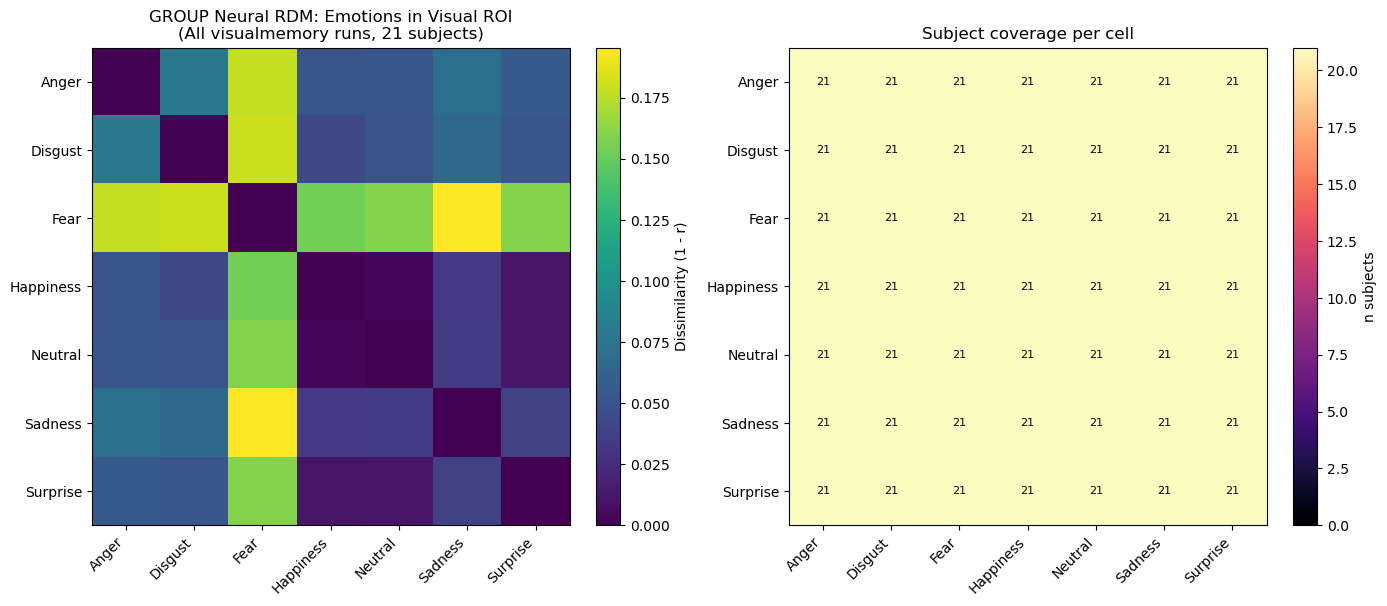

In [1]:
#
import os, re, glob, urllib.request, numpy as np, pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

DERIV_SHARED = "/home/jovyan/shared/data/heatherbrain/Grand_Budapest_Hotel_study/ds007384"
RAW_S3   = "https://s3.amazonaws.com/openneuro.org/ds007329"
S3_DERIV = "https://s3.amazonaws.com/openneuro.org/ds007384"
CACHE    = os.path.expanduser("~/budapest_cache");   os.makedirs(CACHE, exist_ok=True)
RESULTS  = os.path.expanduser("~/budapest_results"); os.makedirs(RESULTS, exist_ok=True)
DELETE_BOLD_AFTER_USE = True

def fetch(sub, ses, fname):
    rel = f"{sub}/{ses}/func/{fname}"
    shared = os.path.join(DERIV_SHARED, rel)
    if os.path.exists(shared): return shared, False
    local = os.path.join(CACHE, rel)
    os.makedirs(os.path.dirname(local), exist_ok=True)
    if not os.path.exists(local):
        urllib.request.urlretrieve(f"{S3_DERIV}/{rel}", local)
    return local, True

ratings = pd.read_csv(f"{RAW_S3}/derivatives/stimuli/labels/behavioral-ratings.tsv", sep="\t")
ALL_EMOTIONS = ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']
MOTION = ["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]
SESSIONS = ["ses-1", "ses-2"]
subjects = sorted(d for d in os.listdir(DERIV_SHARED) if d.startswith("sub-") and not d.endswith(".html"))

for sub in subjects:
    out = os.path.join(RESULTS, f"{sub}_rdm.npy")
    if os.path.exists(out):
        print(f"{sub}: already done, skipping"); continue
    try:
        print(f"{sub}:", end=" ", flush=True)
        bold_loc,_ = fetch(sub,"ses-1",f"{sub}_ses-1_task-localizer_run-01_space-T1w_desc-preproc_bold.nii.gz")
        mask_loc,_ = fetch(sub,"ses-1",f"{sub}_ses-1_task-localizer_run-01_space-T1w_desc-brain_mask.nii.gz")
        conf_loc,_ = fetch(sub,"ses-1",f"{sub}_ses-1_task-localizer_run-01_desc-confounds_timeseries.tsv")
        ev_loc = pd.read_csv(f"{RAW_S3}/{sub}/ses-1/func/{sub}_ses-1_task-localizer_run-01_events.tsv", sep="\t")
        ev_loc = ev_loc[ev_loc["stim_type"].isin(["faces","bodies","objects","scenes","scrambled_objects"])][["onset","duration","stim_type"]].rename(columns={"stim_type":"trial_type"})
        cf_loc = pd.read_csv(conf_loc, sep="\t")[MOTION].fillna(0)
        glm_loc = FirstLevelModel(t_r=1.0, mask_img=mask_loc, high_pass=1/128, smoothing_fwhm=5).fit(bold_loc, events=ev_loc, confounds=cf_loc)
        visual_z = glm_loc.compute_contrast("0.2*faces + 0.2*bodies + 0.2*objects + 0.2*scenes + 0.2*scrambled_objects", output_type="z_score")
        roi_mask = math_img("img > 3.1", img=visual_z)
        if int(roi_mask.get_fdata().sum()) < 100:
            roi_mask = math_img("img > 2.3", img=visual_z)
        masker = NiftiMasker(mask_img=roi_mask).fit()

        emo_vectors, n_runs = {}, 0
        for ses in SESSIONS:
            func = f"{DERIV_SHARED}/{sub}/{ses}/func"
            if not os.path.isdir(func): continue
            for run in sorted(set(re.findall(r'task-visualmemory_(run-\d+)', " ".join(os.listdir(func))))):
                try:
                    bold,tmp = fetch(sub,ses,f"{sub}_{ses}_task-visualmemory_{run}_space-T1w_desc-preproc_bold.nii.gz")
                    mask,_   = fetch(sub,ses,f"{sub}_{ses}_task-visualmemory_{run}_space-T1w_desc-brain_mask.nii.gz")
                    conf,_   = fetch(sub,ses,f"{sub}_{ses}_task-visualmemory_{run}_desc-confounds_timeseries.tsv")
                    ev = pd.read_csv(f"{RAW_S3}/{sub}/{ses}/func/{sub}_{ses}_task-visualmemory_{run}_events.tsv", sep="\t")
                    ev = ev.merge(ratings, left_on="trial_type", right_on="clip", how="left")
                    ev["trial_type"] = ev["emotion"].str.capitalize()
                    ev = ev[["onset","duration","trial_type"]].dropna()
                    if not ev.empty:
                        cf = pd.read_csv(conf, sep="\t")[MOTION].fillna(0)
                        glm = FirstLevelModel(t_r=1.0, mask_img=mask, high_pass=1/128, smoothing_fwhm=5).fit(bold, events=ev, confounds=cf)
                        for e in sorted(ev["trial_type"].unique()):
                            emo_vectors.setdefault(e, []).append(masker.transform(glm.compute_contrast(e, output_type="effect_size")))
                        n_runs += 1
                    if DELETE_BOLD_AFTER_USE and tmp and os.path.exists(bold): os.remove(bold)
                except Exception as re_err:
                    print(f"[{ses} {run} skip]", end=" ")

        present = [e for e in ALL_EMOTIONS if e in emo_vectors]
        patterns = np.vstack([np.mean(np.vstack(emo_vectors[e]), axis=0, keepdims=True) for e in present])
        sub_rdm = squareform(pdist(patterns, metric="correlation"))
        full = np.full((7,7), np.nan)
        for i,a in enumerate(ALL_EMOTIONS):
            for j,b in enumerate(ALL_EMOTIONS):
                if a in present and b in present:
                    full[i,j] = sub_rdm[present.index(a), present.index(b)]
        np.save(out, full)          # saved immediately -> safe to interrupt after this line
        print(f"{n_runs} runs, {len(present)}/7 emotions -> SAVED")
    except Exception as e:
        print(f"-> Failed: {e}")

# ---- Build the group RDM from everything saved so far (works even if only partial) ----
files = sorted(glob.glob(f"{RESULTS}/*_rdm.npy"))
used  = [os.path.basename(f).replace("_rdm.npy","") for f in files]
stack = np.stack([np.load(f) for f in files])
mean_rdm = np.nanmean(stack, axis=0); cov = np.sum(~np.isnan(stack), axis=0)
print(f"\nGroup RDM built from {len(used)} subjects: {used}")

fig, axes = plt.subplots(1, 2, figsize=(14,6))
im0 = axes[0].imshow(mean_rdm, cmap="viridis")
axes[0].set_title(f"GROUP Neural RDM: Emotions in Visual ROI\n(All visualmemory runs, {len(used)} subjects)")
plt.colorbar(im0, ax=axes[0], label="Dissimilarity (1 - r)", fraction=0.046)
im1 = axes[1].imshow(cov, cmap="magma", vmin=0); axes[1].set_title("Subject coverage per cell")
for i in range(7):
    for j in range(7):
        axes[1].text(j,i,int(cov[i,j]),ha="center",va="center",color="white" if cov[i,j]<cov.max()/2 else "black",fontsize=8)
plt.colorbar(im1, ax=axes[1], label="n subjects", fraction=0.046)
for ax in axes:
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(ALL_EMOTIONS, rotation=45, ha="right"); ax.set_yticklabels(ALL_EMOTIONS)
plt.tight_layout(); plt.show()

In [1]:
import os, glob, numpy as np, pandas as pd
from scipy import stats

def fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    q = p[order]*m/np.arange(1, m+1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(m); out[order] = np.clip(q, 0, 1); return out

RESULTS = os.path.expanduser("~/budapest_results")
EMO = ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']
stack = np.stack([np.load(f) for f in sorted(glob.glob(f"{RESULTS}/*_rdm.npy"))])
n = stack.shape[0]
print(f"loaded {n} subjects -> computing...")          # should appear instantly

iu = np.triu_indices(7, k=1)
subj_mean = np.array([m[iu].mean() for m in stack])
rows = []
for a in range(7):
    for b in range(a+1, 7):
        vals = stack[:, a, b]
        t, p = stats.ttest_1samp(vals - subj_mean, 0.0)
        lo, hi = stats.t.interval(0.95, n-1, loc=vals.mean(), scale=stats.sem(vals))
        rows.append(dict(pair=f"{EMO[a]}–{EMO[b]}", mean=vals.mean(), ci_lo=lo, ci_hi=hi,
                         t=t, p=p, direction=("more SIMILAR" if t < 0 else "more DISTINCT")))
df = pd.DataFrame(rows)
df["p_FDR"] = fdr(df["p"].values); df["sig"] = np.where(df["p_FDR"] < .05, "*", "")
df = df.sort_values("mean").reset_index(drop=True)
df.to_csv(f"{RESULTS}/pairwise_stats.csv", index=False)
pd.set_option("display.width", 170, "display.max_rows", None)
print(df.round(4).to_string(index=False))

C = [EMO.index(e) for e in ['Happiness','Neutral','Surprise','Sadness']]
within  = np.array([np.mean([m[a,b] for a in range(7) for b in range(a+1,7) if a in C and b in C]) for m in stack])
between = np.array([np.mean([m[a,b] for a in range(7) for b in range(a+1,7) if not (a in C and b in C)]) for m in stack])
t, p = stats.ttest_rel(within, between)
dz = (within-between).mean()/(within-between).std(ddof=1)
print(f"\nCLUSTER TEST: within mean={within.mean():.4f}, between mean={between.mean():.4f}, "
      f"paired t({n-1})={t:.3f}, p={p:.2e}, dz={dz:.2f}")

loaded 21 subjects -> computing...
              pair   mean  ci_lo  ci_hi        t      p     direction  p_FDR sig
 Happiness–Neutral 0.0031 0.0022 0.0041 -14.1205 0.0000  more SIMILAR 0.0000   *
Happiness–Surprise 0.0114 0.0091 0.0137 -12.5165 0.0000  more SIMILAR 0.0000   *
  Neutral–Surprise 0.0115 0.0091 0.0139 -12.3895 0.0000  more SIMILAR 0.0000   *
 Happiness–Sadness 0.0327 0.0244 0.0410  -8.7385 0.0000  more SIMILAR 0.0000   *
   Neutral–Sadness 0.0349 0.0247 0.0451  -7.6700 0.0000  more SIMILAR 0.0000   *
  Sadness–Surprise 0.0383 0.0278 0.0488  -6.6821 0.0000  more SIMILAR 0.0000   *
 Disgust–Happiness 0.0424 0.0362 0.0486  -7.1446 0.0000  more SIMILAR 0.0000   *
   Disgust–Neutral 0.0498 0.0414 0.0581  -5.6291 0.0000  more SIMILAR 0.0000   *
   Anger–Happiness 0.0511 0.0380 0.0641  -6.1707 0.0000  more SIMILAR 0.0000   *
  Disgust–Surprise 0.0514 0.0422 0.0605  -4.7169 0.0001  more SIMILAR 0.0002   *
     Anger–Neutral 0.0520 0.0389 0.0651  -5.5335 0.0000  more SIMILAR 0.00

In [2]:
import numpy as np, glob, os
from scipy import stats
RESULTS = os.path.expanduser("~/budapest_results")
EMO = ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']
clips = {'Neutral':335,'Happiness':284,'Surprise':46,'Sadness':19,'Disgust':11,'Anger':10,'Fear':2}
stack = np.stack([np.load(f) for f in sorted(glob.glob(f"{RESULTS}/*_rdm.npy"))])
mean_rdm = np.nanmean(stack, axis=0)
dist = {EMO[i]: np.nanmean([mean_rdm[i,j] for j in range(7) if j!=i]) for i in range(7)}
for e in sorted(EMO, key=lambda e: clips[e]):
    print(f"{e:10s} {clips[e]:4d} clips   mean dissimilarity to others = {dist[e]:.3f}")
r, p = stats.spearmanr([clips[e] for e in EMO], [dist[e] for e in EMO])
print(f"\nSpearman(clip count, distinctiveness) = {r:.2f}, p = {p:.3f}")

Fear          2 clips   mean dissimilarity to others = 0.171
Anger        10 clips   mean dissimilarity to others = 0.081
Disgust      11 clips   mean dissimilarity to others = 0.078
Sadness      19 clips   mean dissimilarity to others = 0.073
Surprise     46 clips   mean dissimilarity to others = 0.055
Happiness   284 clips   mean dissimilarity to others = 0.049
Neutral     335 clips   mean dissimilarity to others = 0.052

Spearman(clip count, distinctiveness) = -0.96, p = 0.000
